# 项目介绍


## 背景描述

本项目基于项目AB实验中的一次给计学检验，致力于根居具休的戴据集，对教据进行分析及可视化，并完整地梳理AB实验的详细过程，编程实现A6测试。最终分析新功能
上线是否对指标带来正面影响，并基于数据反馈给出相关业务建议。

## 数据说明


- 数据集来源： https://www.kaggle.com/datasets/aizakpan/ding-tai-fung-x-online-ordering-platform-orders?select=order.csv

- 该数据集是关于网上订餐平台上的鼎泰丰美食的订单，自4月1日起，该店铺决定在平台上的订餐过程中推出一项新功能，以促进销售。

- 该数据集是虚拟数据集，不是真实世界的数据，但产品和价格是基于真实世界的菜单。

# 数据分析

## 加载数据

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rc("font",family='YouYuan')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
plt.rcParams['figure.dpi'] = 100  # 图表基础分辨率
plt.rcParams['savefig.dpi'] = 300  # 保存高清图片
# 加载数据
data_detail = pd.read_csv("detail.csv")
data_menu = pd.read_csv("menu.csv")
data_order = pd.read_csv("order.csv")
display(data_detail.head(),data_menu.head(),data_order.head())


,order_id,item_id,price
0,10001,93,70
1,10001,677,230
2,10001,97,100
3,10002,31,190
4,10002,72,270


,product_id,product_name,category,price
0,66,Pork Xiaolongbao,Xiaolongbao,220
1,67,Crab Roe and Pork Xiaolongbao,Xiaolongbao,370
2,677,Chicken Xiaolongbao,Xiaolongbao,230
3,665,Green Squash and Shrimp Xiaolongbao,Xiaolongbao,340
4,71,Steamed Vegetable and Ground Pork Dumplings,Dumplings & Shao Mai,220


,date,order_id,total
0,2023-01-01,10001,400
1,2023-01-01,10002,750
2,2023-01-01,10003,1020
3,2023-01-01,10004,780
4,2023-01-01,10005,1000


## 合并数据

In [11]:
## 合并数据

data = pd.merge(pd.merge(data_order,data_detail,how='right',on='order_id'),data_menu,how='left',left_on='item_id',right_on='product_id')
data

,date,order_id,total,item_id,price_x,product_id,product_name,category,price_y
0,2023-01-01,10001,400,93,70,93,Steamed Red Bean Rick Cake,Desserts,70
1,2023-01-01,10001,400,677,230,677,Chicken Xiaolongbao,Xiaolongbao,230
2,2023-01-01,10001,400,97,100,97,Steamed Red Bean Rice Cake with Walnuts,Desserts,100
3,2023-01-01,10002,750,31,190,31,Shredded Pork Fried Rice,Fried Rice,190
4,2023-01-01,10002,750,72,270,72,Steamed Shrimp and Pork Dumplings,Dumplings & Shao Mai,270
...,...,...,...,...,...,...,...,...,...
14679,2023-05-17,13829,1610,72,270,72,Steamed Shrimp and Pork Dumplings,Dumplings & Shao Mai,270
14680,2023-05-17,13829,1610,67,370,67,Crab Roe and Pork Xiaolongbao,Xiaolongbao,370
14681,2023-05-17,13829,1610,67,370,67,Crab Roe and Pork Xiaolongbao,Xiaolongbao,370
14682,2023-05-17,13829,1610,97,100,97,Steamed Red Bean Rice Cake with Walnuts,Desserts,100


## 数据清洗

### 检查数据类型

In [ ]:
data['date'] = pd.to_datetime(data['date'],format='%Y-%m-%d')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14684 entries, 0 to 14683
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          14684 non-null  datetime64[ns]
 1   order_id      14684 non-null  int64         
 2   total         14684 non-null  int64         
 3   item_id       14684 non-null  int64         
 4   price_x       14684 non-null  int64         
 5   product_id    14684 non-null  int64         
 6   product_name  14684 non-null  object        
 7   category      14684 non-null  object        
 8   price_y       14684 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 1.0+ MB


In [15]:
# 去重----没有必要去重，因为一个订单可以重复点一个菜
# data = data.drop_duplicates()
# data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    17 non-null     int64 
 1   product_name  17 non-null     object
 2   category      17 non-null     object
 3   price         17 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 676.0+ bytes


None

In [16]:
# 异常值
data.describe([.25,.5,.75,.99])

,date,order_id,total,item_id,price_x,product_id,price_y
count,14684,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,2023-03-13 18:25:53.364206080,12026.146350,871.362708,140.993530,199.283574,140.993530,199.283574
min,2023-01-01 00:00:00,10001.000000,140.000000,29.000000,70.000000,29.000000,70.000000
25%,2023-02-07 00:00:00,11058.000000,610.000000,67.000000,100.000000,67.000000,100.000000
50%,2023-03-16 00:00:00,12090.500000,850.000000,74.000000,220.000000,74.000000,220.000000
75%,2023-04-18 00:00:00,13007.000000,1110.000000,92.000000,250.000000,92.000000,250.000000
99%,2023-05-15 00:00:00,13795.000000,1760.000000,677.000000,370.000000,677.000000,370.000000
max,2023-05-17 00:00:00,13829.000000,2000.000000,677.000000,370.000000,677.000000,370.000000
std,NaN,1115.975084,352.668410,195.447758,93.693049,195.447758,93.693049


In [17]:

# 查看是否有空值
data.isnull().any()

date            False
order_id        False
total           False
item_id         False
price_x         False
product_id      False
product_name    False
category        False
price_y         False
dtype: bool

## 选取需要的字段


In [ ]:

# 删除、重命名字段
data = data.drop('product_id',axis=1).drop('price_y',axis=1)
data.rename(columns={'price_x':'price'},inplace = True)
data = data[['date','order_id','item_id','price','product_name','category','total']]
data

,date,order_id,item_id,price,product_name,category,total
0,2023-01-01,10001,93,70,Steamed Red Bean Rick Cake,Desserts,400
1,2023-01-01,10001,677,230,Chicken Xiaolongbao,Xiaolongbao,400
2,2023-01-01,10001,97,100,Steamed Red Bean Rice Cake with Walnuts,Desserts,400
3,2023-01-01,10002,31,190,Shredded Pork Fried Rice,Fried Rice,750
4,2023-01-01,10002,72,270,Steamed Shrimp and Pork Dumplings,Dumplings & Shao Mai,750
...,...,...,...,...,...,...,...
14679,2023-05-17,13829,72,270,Steamed Shrimp and Pork Dumplings,Dumplings & Shao Mai,1610
14680,2023-05-17,13829,67,370,Crab Roe and Pork Xiaolongbao,Xiaolongbao,1610
14681,2023-05-17,13829,67,370,Crab Roe and Pork Xiaolongbao,Xiaolongbao,1610
14682,2023-05-17,13829,97,100,Steamed Red Bean Rice Cake with Walnuts,Desserts,1610


In [20]:
# 翻译字段
productTranslation_dict = {
    'Steamed Red Bean Rick Cake': '红豆糯米糕',
    'Chicken Xiaolongbao': '鸡肉小笼包',
    'Steamed Red Bean Rice Cake with Walnuts': '核桃红豆年糕',
    'Shredded Pork Fried Rice': '肉丝炒饭',
    'Steamed Shrimp and Pork Dumplings': '虾肉猪肉水饺',
    'Shrimp and Shredded Pork Fried Rice': '虾肉肉丝炒饭',
    'Steamed Fish Dumplings': '鱼肉水饺',
    'Shrimp Fried Rice': '虾肉炒饭',
    'Steamed Chinese Style Layer Cake': '中国风蛋糕',
    'Green Squash and Shrimp Xiaolongbao': '青南瓜虾肉小笼包',
    'Pork Xiaolongbao': '猪肉小笼包',
    'Steamed Vegetable and Ground Pork Dumplings': '蔬菜猪肉水饺',
    'Vegetarian Mushroom Buns': '素馅馒头',
    'Vegetable and Ground Pork Buns': '蔬菜猪肉馅包',
    'Pork Buns': '猪肉包子',
    'Crab Roe and Pork Xiaolongbao': '蟹黄猪肉小笼包',
    'Steamed Vegetarian Mushroom Dumplings': '素馅蒸饺'
}
categoryTranslation_dict = {
    'Desserts': '甜点',
    'Xiaolongbao': '小笼包',
    'Fried Rice': '炒饭',
    'Dumplings & Shao Mai': '饺子与烧卖',
    'Buns': '馒头'
}
data['product_name'] = data['product_name'].map(productTranslation_dict)
data['category'] = data['category'].map(categoryTranslation_dict)
data

,date,order_id,item_id,price,product_name,category,total
0,2023-01-01,10001,93,70,红豆糯米糕,甜点,400
1,2023-01-01,10001,677,230,鸡肉小笼包,小笼包,400
2,2023-01-01,10001,97,100,核桃红豆年糕,甜点,400
3,2023-01-01,10002,31,190,肉丝炒饭,炒饭,750
4,2023-01-01,10002,72,270,虾肉猪肉水饺,饺子与烧卖,750
...,...,...,...,...,...,...,...
14679,2023-05-17,13829,72,270,虾肉猪肉水饺,饺子与烧卖,1610
14680,2023-05-17,13829,67,370,蟹黄猪肉小笼包,小笼包,1610
14681,2023-05-17,13829,67,370,蟹黄猪肉小笼包,小笼包,1610
14682,2023-05-17,13829,97,100,核桃红豆年糕,甜点,1610


## 建立指标


订单的指标：

- 每日订单数量order

- 每日点菜数量item

- 每日每个订单平均点菜数量avg_item、菜价avg_itemPrice

- 每日销售额sales、订单平均销售额avg_sales

- 不同菜系在当日销售的数量和销售额占比

- 不同菜品在当日销售的数量和销售额占比

In [23]:
data.head()

,date,order_id,item_id,price,product_name,category,total
0,2023-01-01,10001,93,70,红豆糯米糕,甜点,400
1,2023-01-01,10001,677,230,鸡肉小笼包,小笼包,400
2,2023-01-01,10001,97,100,核桃红豆年糕,甜点,400
3,2023-01-01,10002,31,190,肉丝炒饭,炒饭,750
4,2023-01-01,10002,72,270,虾肉猪肉水饺,饺子与烧卖,750


In [24]:
# 1. 订单数量（按日期统计不同order_id的数量）
order_count = data.groupby("date")["order_id"].nunique().rename("order")

# 2. 点菜数量（按日期统计总菜品记录数）
item_count = data.groupby("date")["item_id"].count().rename("item")

# 3. 每个订单平均点菜数量
avg_item = (item_count / order_count).rename("avg_item")

# 4. 菜价（菜品单价的平均值）
avg_itemPrice = data.groupby("date")["price"].mean().rename("avg_itemPrice")

# 5. 销售额（按日期统计所有订单的总价之和）
sales = data.drop_duplicates("order_id").groupby("date")["total"].sum().rename("sales")

# 6. 订单平均销售额
avg_sales = (sales / order_count).rename("avg_sales")

In [25]:
# 先计算当日总数量和总销售额（用于计算占比）
daily_total = data.groupby("date").agg(
    total_item_count=("item_id", "count"),
    total_sales=("price", "sum")
).reset_index()

# 7. 不同菜系当日销售数量 & 销售额占比
category_daily = data.groupby(["date", "category"]).agg(
    category_item_count=("item_id", "count"),
    category_sales=("price", "sum")
).reset_index()
category_daily = category_daily.merge(daily_total, on="date")
category_daily["item_count_ratio"] = category_daily["category_item_count"] / category_daily["total_item_count"]
category_daily["sales_ratio"] = category_daily["category_sales"] / category_daily["total_sales"]

# 8. 不同菜品当日销售数量 & 销售额占比
product_daily = data.groupby(["date", "product_name"]).agg(
    product_item_count=("item_id", "count"),
    product_sales=("price", "sum")
).reset_index()
product_daily = product_daily.merge(daily_total, on="date")
product_daily["item_count_ratio"] = product_daily["product_item_count"] / product_daily["total_item_count"]
product_daily["sales_ratio"] = product_daily["product_sales"] / product_daily["total_sales"]

In [27]:
# 合并基础指标
metrics = pd.concat([order_count, item_count, avg_item, avg_itemPrice, sales, avg_sales], axis=1).reset_index()

display(metrics,category_daily,product_daily)


,date,order,item,avg_item,avg_itemPrice,sales,avg_sales
0,2023-01-01,29,100,3.448276,201.000000,20100,693.103448
1,2023-01-02,28,98,3.500000,201.734694,19770,706.071429
2,2023-01-03,28,90,3.214286,187.555556,16880,602.857143
3,2023-01-04,28,102,3.642857,217.941176,22230,793.928571
4,2023-01-05,28,104,3.714286,198.942308,20690,738.928571
...,...,...,...,...,...,...,...
132,2023-05-13,29,133,4.586207,199.548872,26540,915.172414
133,2023-05-14,29,119,4.103448,207.142857,24650,850.000000
134,2023-05-15,29,123,4.241379,198.292683,24390,841.034483
135,2023-05-16,28,120,4.285714,185.333333,22240,794.285714


,date,category,category_item_count,category_sales,total_item_count,total_sales,item_count_ratio,sales_ratio
0,2023-01-01,小笼包,22,5740,100,20100,0.220000,0.285572
1,2023-01-01,炒饭,22,5630,100,20100,0.220000,0.280100
2,2023-01-01,甜点,23,1970,100,20100,0.230000,0.098010
3,2023-01-01,饺子与烧卖,23,5800,100,20100,0.230000,0.288557
4,2023-01-01,馒头,10,960,100,20100,0.100000,0.047761
...,...,...,...,...,...,...,...,...
677,2023-05-16,饺子与烧卖,31,7480,120,22240,0.258333,0.336331
678,2023-05-16,馒头,19,1760,120,22240,0.158333,0.079137
679,2023-05-17,小笼包,2,740,6,1610,0.333333,0.459627
680,2023-05-17,甜点,1,100,6,1610,0.166667,0.062112


,date,product_name,product_item_count,product_sales,total_item_count,total_sales,item_count_ratio,sales_ratio
0,2023-01-01,中国风蛋糕,4,280,100,20100,0.040000,0.013930
1,2023-01-01,核桃红豆年糕,12,1200,100,20100,0.120000,0.059701
2,2023-01-01,猪肉包子,1,90,100,20100,0.010000,0.004478
3,2023-01-01,猪肉小笼包,4,880,100,20100,0.040000,0.043781
4,2023-01-01,素馅蒸饺,1,250,100,20100,0.010000,0.012438
...,...,...,...,...,...,...,...,...
2294,2023-05-16,鸡肉小笼包,3,690,120,22240,0.025000,0.031025
2295,2023-05-17,核桃红豆年糕,1,100,6,1610,0.166667,0.062112
2296,2023-05-17,素馅蒸饺,2,500,6,1610,0.333333,0.310559
2297,2023-05-17,虾肉猪肉水饺,1,270,6,1610,0.166667,0.167702


In [28]:
data

,date,order_id,item_id,price,product_name,category,total
0,2023-01-01,10001,93,70,红豆糯米糕,甜点,400
1,2023-01-01,10001,677,230,鸡肉小笼包,小笼包,400
2,2023-01-01,10001,97,100,核桃红豆年糕,甜点,400
3,2023-01-01,10002,31,190,肉丝炒饭,炒饭,750
4,2023-01-01,10002,72,270,虾肉猪肉水饺,饺子与烧卖,750
...,...,...,...,...,...,...,...
14679,2023-05-17,13829,72,270,虾肉猪肉水饺,饺子与烧卖,1610
14680,2023-05-17,13829,67,370,蟹黄猪肉小笼包,小笼包,1610
14681,2023-05-17,13829,67,370,蟹黄猪肉小笼包,小笼包,1610
14682,2023-05-17,13829,97,100,核桃红豆年糕,甜点,1610


# AB实验

## 实验目的
1. A 组（甜点）、B 组（饺子烧卖）平均订单金额分别是多少？
2. B 组比 A 组高 / 低多少？提升率是多少？
3. 这个差异是真的有区别，还是只是运气 / 样本波动？（p 值 < 0.05？）

## AB实验的类型
1. 很多人以为 AB 测试一定是：
> 随机分流用户 → 改功能 / 改页面 → 看效果
2. 但这段代码做的是另一类非常常见的业务分析：
> 观测型 AB 对比（非严格随机实验）
- 不是 “随机把用户分成两组做策略”而是按品类天然分组，事后对比两组订单的金额表现
- 目的：品类价值对比、品类效果评估，而不是验证某个功能改动
- 所以它的定位是：业务效果对比分析 + 统计显著性校验

数据预处理完成：原始14684行 → 预处理后3791行
分组完成：A组1922条，B组1217条

=== 描述性统计结果 ===
         count    mean  median     std  min   max
分组                                               
A组(对照组)   1922  743.54   730.0  340.91  140  1680
B组(测试组)   1217  832.81   800.0  305.74  310  1680

正态性检验：A组p值=0.0000，B组p值=0.0000
数据是否符合正态分布：False

=== Mann-Whitney U检验结果 ===
p值：0.0000
差异是否显著（p<0.05）：True
A组均值：743.54，B组均值：832.81
B组相对A组提升率：12.01%

可视化结果已保存为：ab_test_result.png


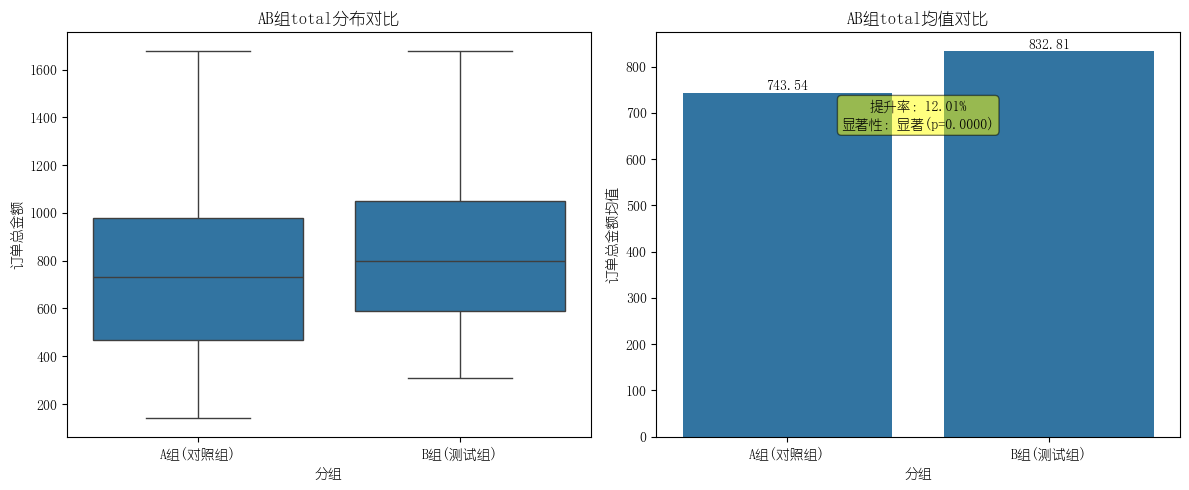

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（解决matplotlib中文显示乱码问题）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def preprocess_data(df):
    """
    适配你的data数据：按order_id聚合，处理单订单多商品的情况
    """
    # 同一个order_id的total是相同的，直接取第一个值即可
    df_agg = df.groupby('order_id').agg({
        'total': 'first',          # 订单总金额（原total列）
        'category': lambda x: ','.join(x.unique()),  # 订单包含的所有品类
        'date': 'first'            # 订单日期
    }).reset_index()
    
    # 过滤异常值：总金额>0 且 小于99%分位数
    q99 = df_agg['total'].quantile(0.99)
    df_agg = df_agg[(df_agg['total'] > 0) & (df_agg['total'] <= q99)]
    
    # 补全缺失值
    df_agg = df_agg.fillna({'category': '未知', 'date': pd.NaT})
    
    print(f"数据预处理完成：原始{len(df)}行 → 预处理后{len(df_agg)}行")
    return df_agg

def split_ab_groups(df, group_method='category', category_a='甜点', category_b='饺子与烧卖'):
    """
    划分AB组：按品类分组（适配你的category列）
    """
    df_copy = df.copy()
    
    if group_method == 'category':
        df_copy['分组'] = np.where(
            df_copy['category'].str.contains(category_a, na=False),
            'A组(对照组)',
            np.where(
                df_copy['category'].str.contains(category_b, na=False),
                'B组(测试组)',
                '未分组'
            )
        )
    elif group_method == 'random':
        np.random.seed(42)
        df_copy['分组'] = np.random.choice(
            ['A组(对照组)', 'B组(测试组)'],
            size=len(df_copy),
            p=[0.5, 0.5]
        )
    elif group_method == 'time':
        df_copy['date'] = pd.to_datetime(df_copy['date'])
        mid_date = df_copy['date'].median()
        df_copy['分组'] = np.where(
            df_copy['date'] <= mid_date, 'A组(对照组)', 'B组(测试组)'
        )
    else:
        raise ValueError("分组方式仅支持：category/random/time")
    
    df_ab = df_copy[df_copy['分组'].isin(['A组(对照组)', 'B组(测试组)'])].reset_index(drop=True)
    print(f"分组完成：A组{len(df_ab[df_ab['分组']=='A组(对照组)'])}条，B组{len(df_ab[df_ab['分组']=='B组(测试组)'])}条")
    return df_ab

def ab_test_analysis(df_ab, metric='total'):
    """
    AB测试核心分析：描述性统计 + 假设检验
    """
    desc_stats = df_ab.groupby('分组')[metric].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    print("\n=== 描述性统计结果 ===")
    print(desc_stats)
    
    group_a = df_ab[df_ab['分组']=='A组(对照组)'][metric]
    group_b = df_ab[df_ab['分组']=='B组(测试组)'][metric]
    
    # 正态性检验
    shapiro_a = stats.shapiro(group_a)
    shapiro_b = stats.shapiro(group_b)
    is_normal = (shapiro_a.pvalue > 0.05) and (shapiro_b.pvalue > 0.05)
    
    print(f"\n正态性检验：A组p值={shapiro_a.pvalue:.4f}，B组p值={shapiro_b.pvalue:.4f}")
    print(f"数据是否符合正态分布：{is_normal}")
    
    # 选择检验方法
    if is_normal:
        t_test = stats.ttest_ind(group_a, group_b, equal_var=False)
        test_method = "独立样本t检验"
        p_value = t_test.pvalue
    else:
        mw_test = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
        test_method = "Mann-Whitney U检验"
        p_value = mw_test.pvalue
    
    # 计算提升率
    mean_a, mean_b = group_a.mean(), group_b.mean()
    lift_rate = (mean_b - mean_a) / mean_a * 100 if mean_a != 0 else 0
    
    result = {
        'test_method': test_method,
        'p_value': p_value,
        'is_significant': p_value < 0.05,
        'mean_a': mean_a,
        'mean_b': mean_b,
        'lift_rate': lift_rate
    }
    
    print(f"\n=== {test_method}结果 ===")
    print(f"p值：{p_value:.4f}")
    print(f"差异是否显著（p<0.05）：{result['is_significant']}")
    print(f"A组均值：{mean_a:.2f}，B组均值：{mean_b:.2f}")
    print(f"B组相对A组提升率：{lift_rate:.2f}%")
    
    return result

def visualize_ab_result(df_ab, metric='total', result=None):
    """
    可视化AB测试结果
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 箱线图：展示分布
    sns.boxplot(x='分组', y=metric, data=df_ab, ax=ax1)
    ax1.set_title(f'AB组{metric}分布对比', fontsize=12)
    ax1.set_xlabel('分组')
    ax1.set_ylabel('订单总金额')
    
    # 柱状图：展示均值
    mean_data = df_ab.groupby('分组')[metric].mean().reset_index()
    sns.barplot(x='分组', y=metric, data=mean_data, ax=ax2)
    ax2.set_title(f'AB组{metric}均值对比', fontsize=12)
    ax2.set_xlabel('分组')
    ax2.set_ylabel('订单总金额均值')
    
    # 标注数值
    for i, row in mean_data.iterrows():
        ax2.text(i, row[metric]+5, f"{row[metric]:.2f}", ha='center')
    
    # 标注显著性
    if result:
        sig_text = "显著" if result['is_significant'] else "不显著"
        ax2.text(0.5, mean_data[metric].max()*0.8, 
                 f"提升率：{result['lift_rate']:.2f}%\n显著性：{sig_text}(p={result['p_value']:.4f})",
                 ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('ab_test_result.png', dpi=1000, bbox_inches='tight')
    print("\n可视化结果已保存为：ab_test_result.png")
    plt.show()

# ===================== 运行主流程 =====================
if __name__ == "__main__":
    # 直接使用你环境里的data变量
    df_raw = data
    
    # 步骤1：数据预处理
    df_processed = preprocess_data(df_raw)
    
    # 步骤2：划分AB组（按品类：甜点=对照组，饺子与烧卖=测试组）
    df_ab = split_ab_groups(
        df_processed,
        group_method='category',
        category_a='甜点',
        category_b='饺子与烧卖'
    )
    
    # 步骤3：核心分析
    test_result = ab_test_analysis(df_ab, metric='total')
    
    # 步骤4：可视化
    visualize_ab_result(df_ab, metric='total', result=test_result)